<a href="https://colab.research.google.com/github/DHung154/Thuchanh_DeepLearning/blob/main/BaiTap_LinearRegression_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression - Dự đoán giá nhà
**Data:** GitHub thầy Huỳnh Hộc → `23_HOMES.csv`  
**Pipeline:** Split First → Fit on Train → Transform → Train → Evaluate

##  Bước 1: Clone repo từ GitHub

In [ ]:
import os

# Clone repo thầy về Colab
if not os.path.exists('DataAnalystDeepLearning'):
    !git clone https://github.com/huynhhoc/DataAnalystDeepLearning.git
    print('✅ Clone xong!')
else:
    print('✅ Repo đã có rồi!')

# Kiểm tra data có không
data_path = 'DataAnalystDeepLearning/Data/23_HOMES.csv'
print(f'\nFile tồn tại: {os.path.exists(data_path)}')
print(f'Đường dẫn  : {data_path}')

Cloning into 'DataAnalystDeepLearning'...
remote: Enumerating objects: 544, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 544 (delta 18), reused 15 (delta 6), pack-reused 501 (from 1)
Receiving objects: 100% (544/544), 43.55 MiB | 17.80 MiB/s, done.
Resolving deltas: 100% (242/242), done.
✅ Clone xong!

File tồn tại: True
Đường dẫn  : DataAnalystDeepLearning/Data/23_HOMES.csv


## Bước 2: Import thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('✅ Import thư viện xong!')

✅ Import thư viện xong!


## Bước 3: Load và khám phá dữ liệu

In [ ]:
df = pd.read_csv('DataAnalystDeepLearning/Data/23_HOMES.csv')

print(f'Shape: {df.shape}  →  {df.shape[0]} nhà, {df.shape[1]} cột')
print(f'Null values: {df.isnull().sum().sum()}')
df.head()

Shape: (40, 9)  →  40 nhà, 9 cột
Null values: 0


,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
0,400000,414000,2704,2.27,27,4920,9,3,3
1,370000,379000,2096,0.75,21,4113,8,4,2
2,382500,389900,2737,1.00,36,6072,9,4,2
3,300000,299900,1800,0.43,34,4024,8,4,2
4,305000,319900,1066,3.60,69,3562,6,3,2


In [ ]:
df.describe()

,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,342672.500000,349937.500000,2058.375000,1.690250,38.125000,4626.625000,7.675000,3.300000,1.900000
std,83236.659784,84592.348831,657.934674,2.007324,22.944959,1848.538947,1.654636,0.723241,0.744208
min,210000.000000,219900.000000,1066.000000,0.250000,6.000000,1367.000000,4.000000,2.000000,1.000000
25%,292000.000000,294975.000000,1646.250000,0.667500,24.750000,3479.750000,6.000000,3.000000,1.000000
50%,309000.000000,319900.000000,1855.000000,1.000000,35.500000,4129.500000,8.000000,3.000000,2.000000
75%,388750.000000,395925.000000,2412.000000,1.880000,46.250000,5530.250000,9.000000,4.000000,2.000000
max,520000.000000,529700.000000,3867.000000,11.580000,144.000000,9809.000000,11.000000,5.000000,4.000000


## Bước 4: Visualize dữ liệu

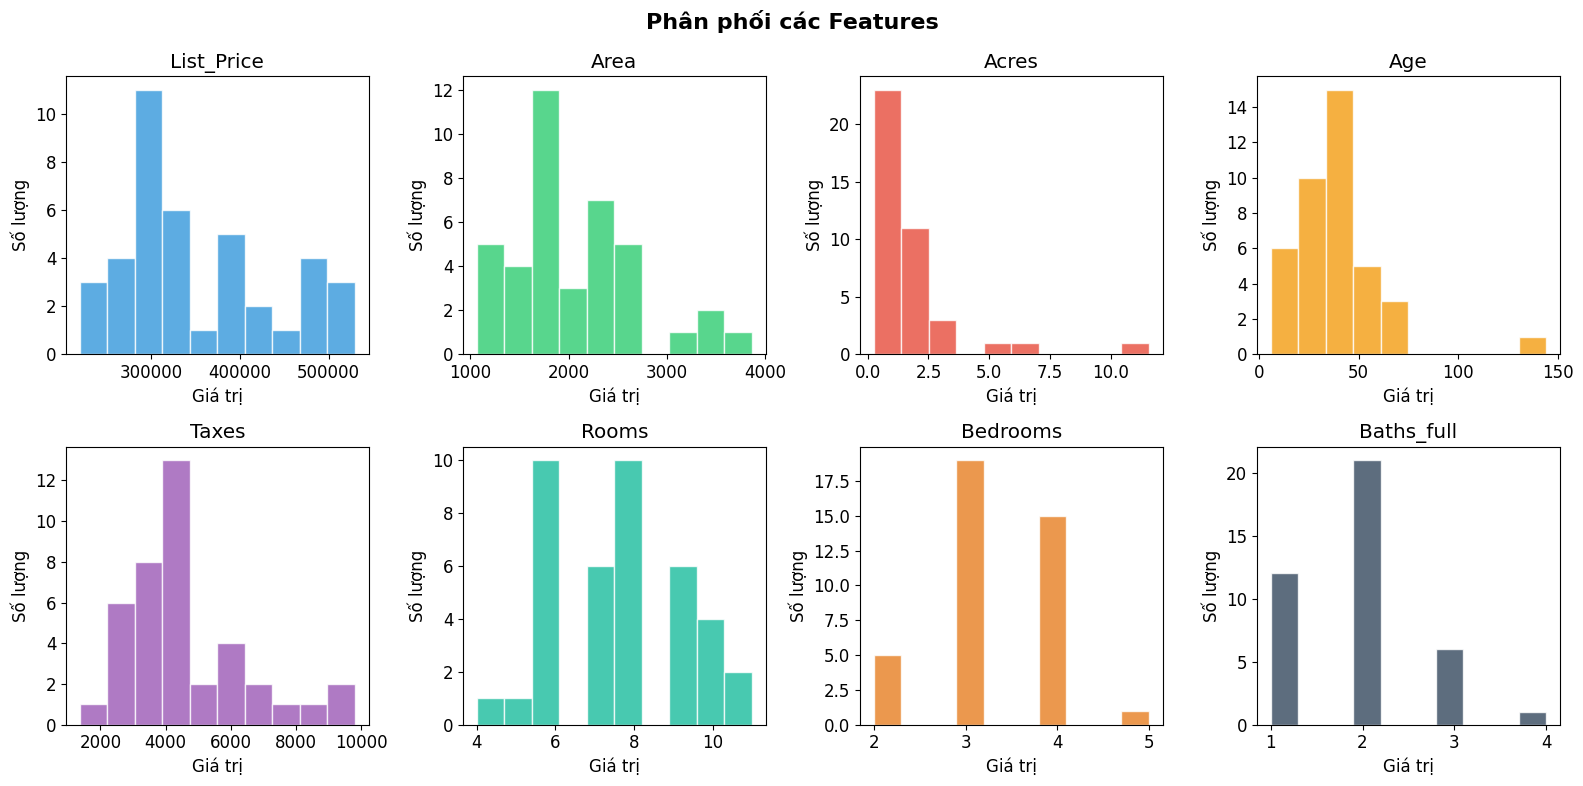

✅ Lưu: 1_feature_distributions.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Phân phối các Features', fontsize=16, fontweight='bold')

feature_cols = ['List_Price', 'Area', 'Acres', 'Age', 'Taxes', 'Rooms', 'Bedrooms', 'Baths_full']
colors = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e']

for i, (col, color) in enumerate(zip(feature_cols, colors)):
    ax = axes[i//4][i%4]
    ax.hist(df[col], bins=10, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Giá trị')
    ax.set_ylabel('Số lượng')

plt.tight_layout()
plt.savefig('1_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu: 1_feature_distributions.png')

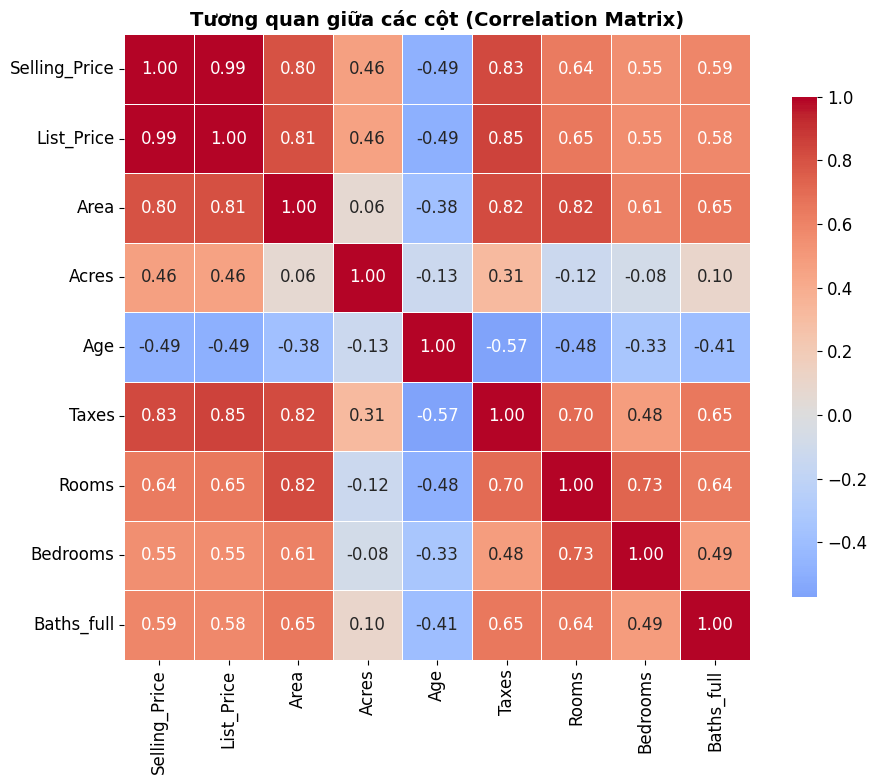

✅ Lưu: 2_correlation_heatmap.png


In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Tương quan giữa các cột (Correlation Matrix)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu: 2_correlation_heatmap.png')

## Bước 5: SPLIT FIRST (tránh Data Leakage!)

Tổng data : 40 mẫu
Train set : 32 mẫu (80%)
Test set  : 8 mẫu (20%)


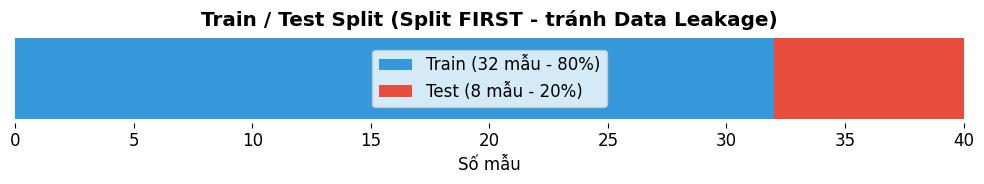

✅ Lưu: 3_train_test_split.png


In [ ]:
X = df[feature_cols]
y = df['Selling_Price']

# SPLIT FIRST - đúng theo slide thầy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Tổng data : {len(df)} mẫu')
print(f'Train set : {len(X_train)} mẫu ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test set  : {len(X_test)} mẫu ({len(X_test)/len(df)*100:.0f}%)')

# Vẽ sơ đồ split
fig, ax = plt.subplots(figsize=(10, 2))
ax.barh(0, len(X_train), color='#3498db', label=f'Train ({len(X_train)} mẫu - 80%)')
ax.barh(0, len(X_test), left=len(X_train), color='#e74c3c', label=f'Test ({len(X_test)} mẫu - 20%)')
ax.set_xlim(0, len(df))
ax.set_yticks([])
ax.set_xlabel('Số mẫu')
ax.set_title('Train / Test Split (Split FIRST - tránh Data Leakage)', fontweight='bold')
ax.legend(loc='center')
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
plt.savefig('3_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu: 3_train_test_split.png')

## Bước 6: StandardScaler - Chuẩn hóa dữ liệu

In [ ]:
scaler = StandardScaler()

# fit() CHỈ trên train
scaler.fit(X_train)

# transform() lên cả train + test
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Công thức: z = (x - μ_train) / σ_train')
print(f'\nSau scale - mean ≈ {X_train_scaled.mean():.4f}  (phải gần 0)')
print(f'Sau scale - std  ≈ {X_train_scaled.std():.4f}  (phải gần 1)')
print('\n✅ fit() chỉ trên X_train → KHÔNG bị Data Leakage!')

Công thức: z = (x - μ_train) / σ_train

Sau scale - mean ≈ -0.0000  (phải gần 0)
Sau scale - std  ≈ 1.0000  (phải gần 1)

✅ fit() chỉ trên X_train → KHÔNG bị Data Leakage!


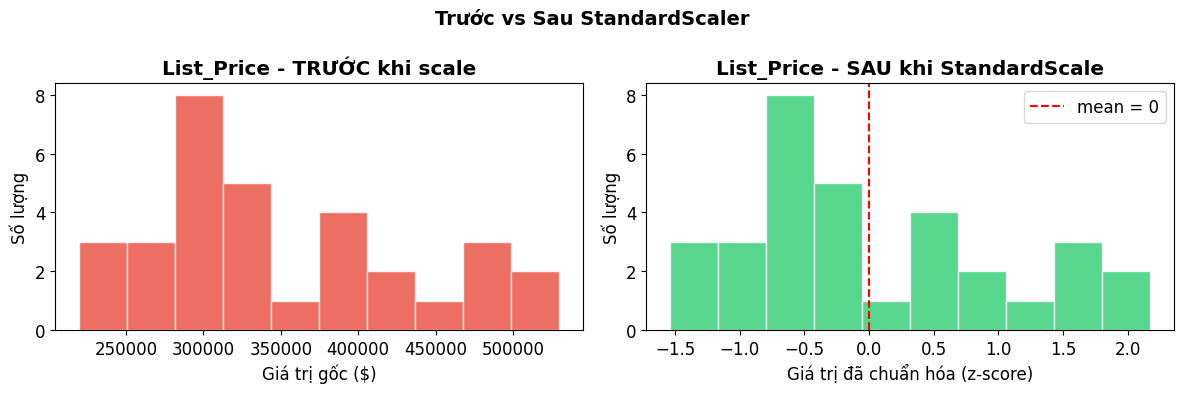

✅ Lưu: 4_before_after_scaling.png


In [ ]:
# Vẽ so sánh trước/sau scale cho feature đầu tiên
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train['List_Price'], bins=10, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_title('List_Price - TRƯỚC khi scale', fontweight='bold')
axes[0].set_xlabel('Giá trị gốc ($)')
axes[0].set_ylabel('Số lượng')

axes[1].hist(X_train_scaled[:, 0], bins=10, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].set_title('List_Price - SAU khi StandardScale', fontweight='bold')
axes[1].set_xlabel('Giá trị đã chuẩn hóa (z-score)')
axes[1].set_ylabel('Số lượng')
axes[1].axvline(0, color='red', linestyle='--', label='mean = 0')
axes[1].legend()

plt.suptitle('Trước vs Sau StandardScaler', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('4_before_after_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu: 4_before_after_scaling.png')

## Bước 7: Train mô hình Linear Regression

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Công thức: W1*x1 + W2*x2 + ... + W8*x8 + b = ŷ')
print(f'\nBias (b) = {model.intercept_:,.2f}')
print('\nTrọng số W:')
for col, w in zip(feature_cols, model.coef_):
    bar = '█' * int(abs(w) / 5000) if abs(w) > 1000 else '▌'
    sign = '+' if w > 0 else '-'
    print(f'  {col:15s} {sign} {bar} W = {w:10.2f}')
print('\n✅ Train xong!')

Công thức: W1*x1 + W2*x2 + ... + W8*x8 + b = ŷ

Bias (b) = 340,575.00

Trọng số W:
  List_Price      + ████████████████ W =   82581.15
  Area            +  W =    2359.97
  Acres           + ▌ W =     549.81
  Age             - ▌ W =    -777.28
  Taxes           -  W =   -3393.78
  Rooms           -  W =   -4961.34
  Bedrooms        +  W =    1481.67
  Baths_full      +  W =    2679.17

✅ Train xong!


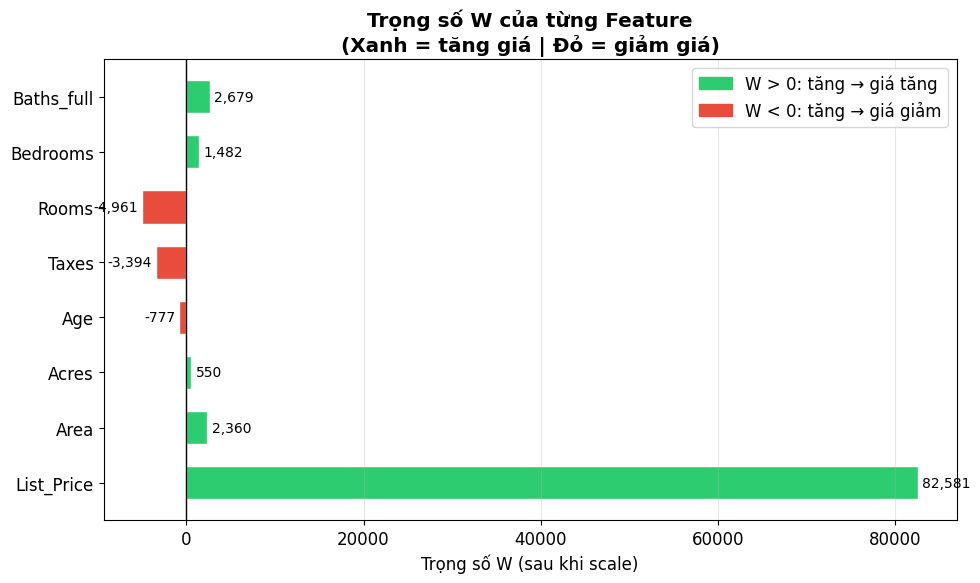

✅ Lưu: 5_feature_weights.png


In [ ]:
# Vẽ trọng số W của từng feature
fig, ax = plt.subplots(figsize=(10, 6))
colors_w = ['#2ecc71' if w > 0 else '#e74c3c' for w in model.coef_]
bars = ax.barh(feature_cols, model.coef_, color=colors_w, edgecolor='white', height=0.6)

for bar, val in zip(bars, model.coef_):
    xpos = val + 500 if val > 0 else val - 500
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', ha='left' if val > 0 else 'right', fontsize=10)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Trọng số W (sau khi scale)')
ax.set_title('Trọng số W của từng Feature\n(Xanh = tăng giá | Đỏ = giảm giá)', fontweight='bold')
green_patch = mpatches.Patch(color='#2ecc71', label='W > 0: tăng → giá tăng')
red_patch   = mpatches.Patch(color='#e74c3c', label='W < 0: tăng → giá giảm')
ax.legend(handles=[green_patch, red_patch])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('5_feature_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu: 5_feature_weights.png')

## Bước 8: Đánh giá mô hình

In [ ]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print('=' * 45)
print('KẾT QUẢ ĐÁNH GIÁ')
print('=' * 45)
print(f'R² Train : {r2_train:.4f}')
print(f'R² Test  : {r2_test:.4f}')
print(f'RMSE Test: ${rmse_test:,.0f}')
print()
print('DỰ ĐOÁN vs THỰC TẾ:')
results = pd.DataFrame({
    'Thực tế ($)'   : y_test.values,
    'Dự đoán ($)'   : y_pred_test.astype(int),
    'Chênh lệch ($)': (y_pred_test - y_test.values).astype(int)
})
print(results.to_string(index=False))

KẾT QUẢ ĐÁNH GIÁ
R² Train : 0.9905
R² Test  : 0.9952
RMSE Test: $5,920

DỰ ĐOÁN vs THỰC TẾ:
 Thực tế ($)  Dự đoán ($)  Chênh lệch ($)
      272500       271303           -1196
      280000       282194            2194
      475000       479303            4303
      499000       498407            -592
      305000       316414           11414
      385000       374261          -10738
      300000       303086            3086
      292000       291700            -299


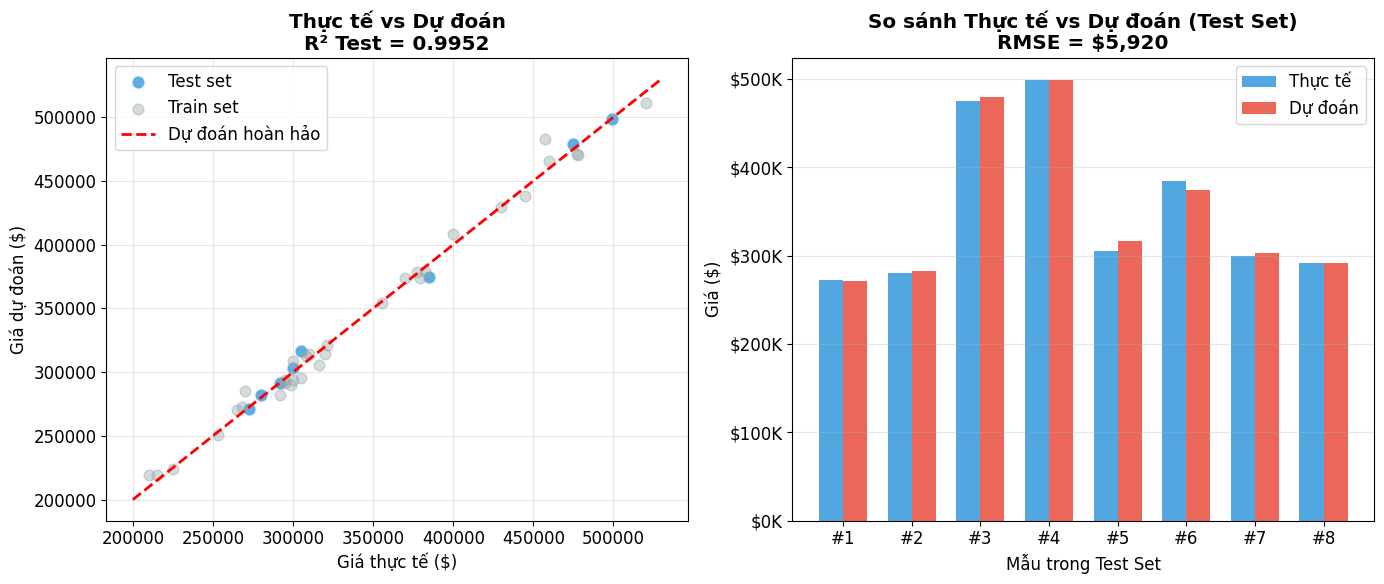

✅ Lưu: 6_actual_vs_predicted.png


In [ ]:
# Biểu đồ: Thực tế vs Dự đoán
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Scatter thực tế vs dự đoán ---
ax1 = axes[0]
ax1.scatter(y_test, y_pred_test, color='#3498db', s=100, alpha=0.8, edgecolors='white', linewidth=1.5, label='Test set')
ax1.scatter(y_train, y_pred_train, color='#95a5a6', s=60, alpha=0.4, label='Train set')
min_val = min(y.min(), y_pred_test.min()) - 10000
max_val = max(y.max(), y_pred_test.max()) + 10000
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Dự đoán hoàn hảo')
ax1.set_xlabel('Giá thực tế ($)')
ax1.set_ylabel('Giá dự đoán ($)')
ax1.set_title(f'Thực tế vs Dự đoán\nR² Test = {r2_test:.4f}', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# --- Plot 2: Bar chart so sánh test set ---
ax2 = axes[1]
x_idx = np.arange(len(y_test))
width = 0.35
bars1 = ax2.bar(x_idx - width/2, y_test.values, width, label='Thực tế', color='#3498db', alpha=0.85)
bars2 = ax2.bar(x_idx + width/2, y_pred_test,   width, label='Dự đoán', color='#e74c3c', alpha=0.85)
ax2.set_xlabel('Mẫu trong Test Set')
ax2.set_ylabel('Giá ($)')
ax2.set_title(f'So sánh Thực tế vs Dự đoán (Test Set)\nRMSE = ${rmse_test:,.0f}', fontweight='bold')
ax2.set_xticks(x_idx)
ax2.set_xticklabels([f'#{i+1}' for i in range(len(y_test))])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('6_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu: 6_actual_vs_predicted.png')

/tmp/ipykernel_847/53054348.py:35: UserWarning: Glyph 128193 (\N{FILE FOLDER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_847/53054348.py:35: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_847/53054348.py:35: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_847/53054348.py:35: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_847/53054348.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_847/53054348.py:36: UserWarning: Glyph 128193 (\N{FILE FOLDER}) missing from font(s) DejaVu Sans.
  plt.savefig('7_pipeline_diagram.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_847/53054348.py:36: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OP

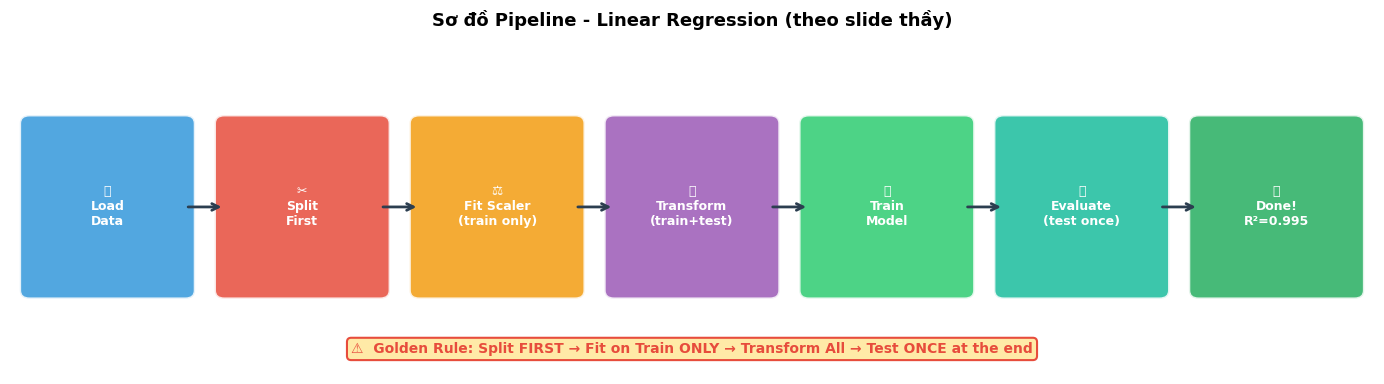

✅ Lưu: 7_pipeline_diagram.png


In [ ]:
import matplotlib.patches as mpatches

# Sơ đồ pipeline toàn bộ quá trình
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis('off')

steps = [
    (1,   '📁\nLoad\nData',        '#3498db'),
    (3,   '✂️\nSplit\nFirst',       '#e74c3c'),
    (5,   '⚖️\nFit Scaler\n(train only)', '#f39c12'),
    (7,   '🔄\nTransform\n(train+test)',  '#9b59b6'),
    (9,   '🧠\nTrain\nModel',       '#2ecc71'),
    (11,  '📊\nEvaluate\n(test once)', '#1abc9c'),
    (13,  '✅\nDone!\nR²=0.995',    '#27ae60'),
]

for x, label, color in steps:
    ax.add_patch(mpatches.FancyBboxPatch((x-0.8, 1), 1.6, 2,
                 boxstyle='round,pad=0.1', facecolor=color, alpha=0.85, edgecolor='white', linewidth=2))
    ax.text(x, 2, label, ha='center', va='center', fontsize=9,
            color='white', fontweight='bold', multialignment='center')

for x, _, _ in steps[:-1]:
    ax.annotate('', xy=(x+1.2, 2), xytext=(x+0.8, 2),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2))

ax.text(7, 0.3, '⚠️  Golden Rule: Split FIRST → Fit on Train ONLY → Transform All → Test ONCE at the end',
        ha='center', va='center', fontsize=10, color='#e74c3c',
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#ffeaa7', edgecolor='#e74c3c', linewidth=1.5))

ax.set_title('Sơ đồ Pipeline - Linear Regression (theo slide thầy)', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('7_pipeline_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lưu: 7_pipeline_diagram.png')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

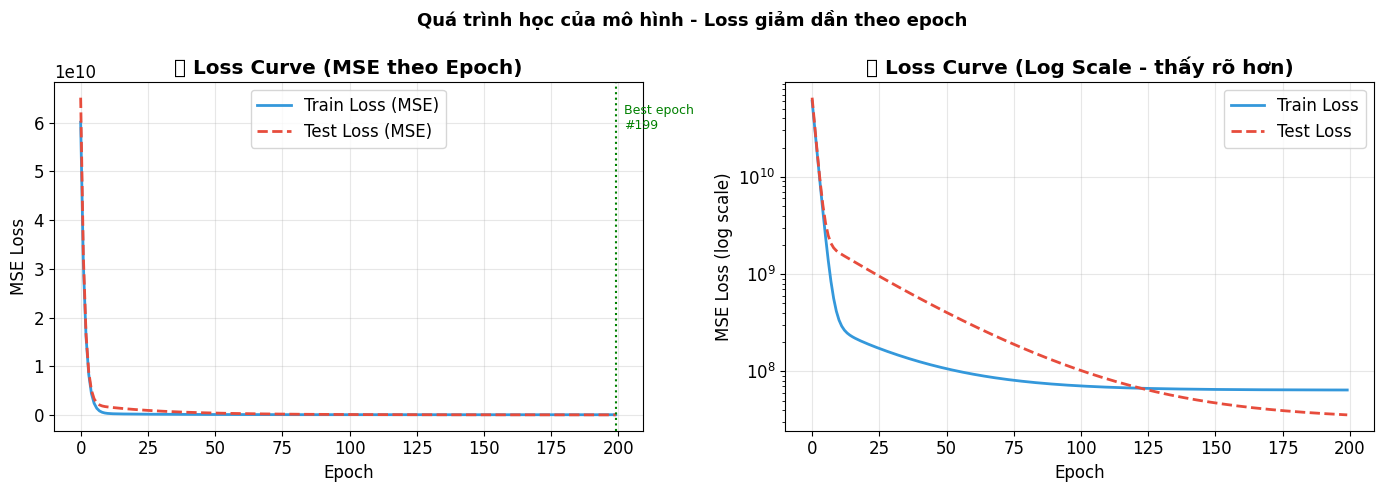

✅ Lưu: 8_loss_curve.png
Loss ban đầu : 60,065,304,099
Loss cuối    : 64,343,914
Giảm được    : 99.9%


In [ ]:
# Vẽ Loss curve (MSE theo từng iteration giả lập)
from sklearn.linear_model import SGDRegressor

losses_train = []
losses_test  = []

# Dùng SGDRegressor để lấy loss từng epoch
sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42, eta0=0.01, learning_rate='constant')

for epoch in range(200):
    sgd.fit(X_train_scaled, y_train)

    loss_train = mean_squared_error(y_train, sgd.predict(X_train_scaled))
    loss_test  = mean_squared_error(y_test,  sgd.predict(X_test_scaled))

    losses_train.append(loss_train)
    losses_test.append(loss_test)

# Vẽ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Loss curve ---
ax1 = axes[0]
ax1.plot(losses_train, color='#3498db', linewidth=2, label='Train Loss (MSE)')
ax1.plot(losses_test,  color='#e74c3c', linewidth=2, label='Test Loss (MSE)',  linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('📉 Loss Curve (MSE theo Epoch)', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Đánh dấu điểm loss thấp nhất
best_epoch = int(np.argmin(losses_test))
ax1.axvline(best_epoch, color='green', linestyle=':', linewidth=1.5)
ax1.text(best_epoch + 3, max(losses_test)*0.9,
         f'Best epoch\n#{best_epoch}', color='green', fontsize=9)

# --- Plot 2: Log scale để thấy rõ hơn ---
ax2 = axes[1]
ax2.plot(losses_train, color='#3498db', linewidth=2, label='Train Loss')
ax2.plot(losses_test,  color='#e74c3c', linewidth=2, label='Test Loss', linestyle='--')
ax2.set_yscale('log')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss (log scale)')
ax2.set_title('📉 Loss Curve (Log Scale - thấy rõ hơn)', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Quá trình học của mô hình - Loss giảm dần theo epoch',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('8_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Lưu: 8_loss_curve.png')
print(f'Loss ban đầu : {losses_train[0]:,.0f}')
print(f'Loss cuối    : {losses_train[-1]:,.0f}')
print(f'Giảm được    : {(1 - losses_train[-1]/losses_train[0])*100:.1f}%')